<a href="https://colab.research.google.com/github/bashirrrmk/ML-Miniprojects-Collection/blob/main/Boosting_HyperparameterTuning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e94560; font-size: 2.2em; font-weight: 900; letter-spacing: 2px; margin-bottom: 8px;"> PREDICTIVE MODELING</h1>
  <h2 style="color: #ffffff; font-size: 1.5em; font-weight: 600; margin-bottom: 6px;">Boosting Techniques + Hyperparameter Tuning</h2>
  <p style="color: #a8b2d8; font-size: 1.05em; margin-bottom: 16px;">XGBoost · LightGBM · CatBoost · GridSearchCV · RandomizedSearchCV</p>
  <hr style="border-color: #e94560; width: 60%; margin: auto;"/>
  <p style="color: #ccd6f6; margin-top: 12px; font-size: 0.95em;">Dataset: <b>Breast Cancer Wisconsin (UCI)</b> &nbsp;|&nbsp; Task: <b>Binary Classification</b></p>
</div>


---
##  Table of Contents
| # | Section |
|---|---|
| 1 | [ Install & Import Libraries](#section1) |
| 2 | [ Load Dataset](#section2) |
| 3 | [ Exploratory Data Analysis (EDA)](#section3) |
| 4 | [ Feature Engineering & Preprocessing](#section4) |
| 5 | [ Train-Test Split](#section5) |
| 6 | [ Baseline Models (Default Params)](#section6) |
| 7 | [ Hyperparameter Tuning — XGBoost](#section7) |
| 8 | [ Hyperparameter Tuning — LightGBM](#section8) |
| 9 | [ Hyperparameter Tuning — CatBoost](#section9) |
| 10 | [ Model Comparison & Final Evaluation](#section10) |
| 11 | [ Feature Importance Analysis](#section11) |
| 12 | [ Conclusion](#section12) |

---

<a id='section1'></a>
##  Section 1 — Install & Import Libraries
All required libraries are installed and imported here, including XGBoost, LightGBM, CatBoost, Scikit-learn, and visualization tools.

 A custom dark theme is applied globally for consistent, portfolio-quality plots throughout the notebook.

In [2]:
# ── Install required libraries (Colab-safe) ──────────────────────────────────
!pip install xgboost lightgbm catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00


In [3]:
# ── Core libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
)

# ── Boosting models ───────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ── Style config ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.alpha':       0.8,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = ['#58a6ff', '#f78166', '#3fb950', '#d2a8ff', '#ffa657', '#79c0ff']
print(' All libraries imported successfully!')

 All libraries imported successfully!


<a id='section2'></a>
##  Section 2 — Load Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset is loaded directly from sklearn.datasets.

It contains 569 samples, 30 numerical features, and a binary target (Malignant / Benign) with no missing values — making it ideal for benchmarking boosting classifiers.

> **Dataset:** Breast Cancer Wisconsin (Diagnostic)  
> **Source:** UCI Machine Learning Repository (also available via `sklearn.datasets`)  
> **Task:** Classify tumors as **Malignant (0)** or **Benign (1)**  
> **Samples:** 569 &nbsp;|&nbsp; **Features:** 30 &nbsp;|&nbsp; **Classes:** 2

In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
raw = load_breast_cancer()
df  = pd.DataFrame(raw.data, columns=raw.feature_names)
df['target'] = raw.target   # 0 = Malignant, 1 = Benign

print(f'Shape          : {df.shape}')
print(f'Features       : {df.shape[1] - 1}')
print(f'Target classes : {dict(zip(raw.target_names, np.bincount(raw.target)))}')
df.head()

Shape          : (569, 31)
Features       : 30
Target classes : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<a id='section3'></a>
##  Section 3 — Exploratory Data Analysis (EDA)

The dataset is analyzed through class distribution charts, feature histograms split by class, a full correlation heatmap, and boxplots of the top 8 most discriminative features.

This step reveals class imbalance, feature separability, and multicollinearity patterns.

In [5]:
# ── 3.1  Basic info ───────────────────────────────────────────────────────────
print('='*55)
print('         DATASET OVERVIEW')
print('='*55)
print(f'  Total samples   : {len(df)}')
print(f'  Total features  : {df.shape[1]-1}')
print(f'  Missing values  : {df.isnull().sum().sum()}')
print(f'  Duplicate rows  : {df.duplicated().sum()}')
print(f'  Memory usage    : {df.memory_usage(deep=True).sum()/1024:.1f} KB')
print('='*55)
df.describe().T.style.background_gradient(cmap='Blues').format('{:.3f}')

         DATASET OVERVIEW
  Total samples   : 569
  Total features  : 30
  Missing values  : 0
  Duplicate rows  : 0
  Memory usage    : 137.9 KB


,count,mean,std,min,25%,50%,75%,max
mean radius,569.000,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.000,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.000,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.000,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.000,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.000,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.000,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.000,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.000,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.000,0.063,0.007,0.050,0.058,0.062,0.066,0.097


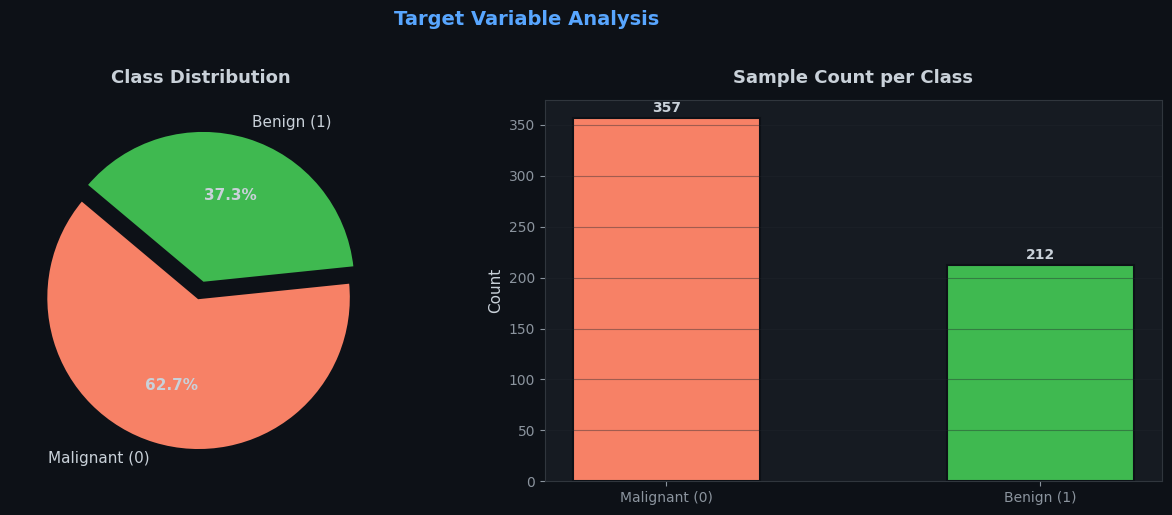

In [6]:
# ── 3.2  Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')

counts  = df['target'].value_counts()
labels  = ['Malignant (0)', 'Benign (1)']
colors  = ['#f78166', '#3fb950']
explode = [0.05, 0.05]

# Pie
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, colors=colors, autopct='%1.1f%%',
    explode=explode, startangle=140,
    textprops={'color': '#c9d1d9', 'fontsize': 11},
    wedgeprops={'linewidth': 2, 'edgecolor': '#0d1117'}
)
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Class Distribution', fontweight='bold', color='#c9d1d9', pad=12)

# Bar
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='#0d1117', linewidth=1.5, width=0.5)
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(v), ha='center', va='bottom', fontweight='bold', color='#c9d1d9')
axes[1].set_title('Sample Count per Class', fontweight='bold', color='#c9d1d9', pad=12)
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', color='#58a6ff', y=1.02)
plt.tight_layout()
plt.show()

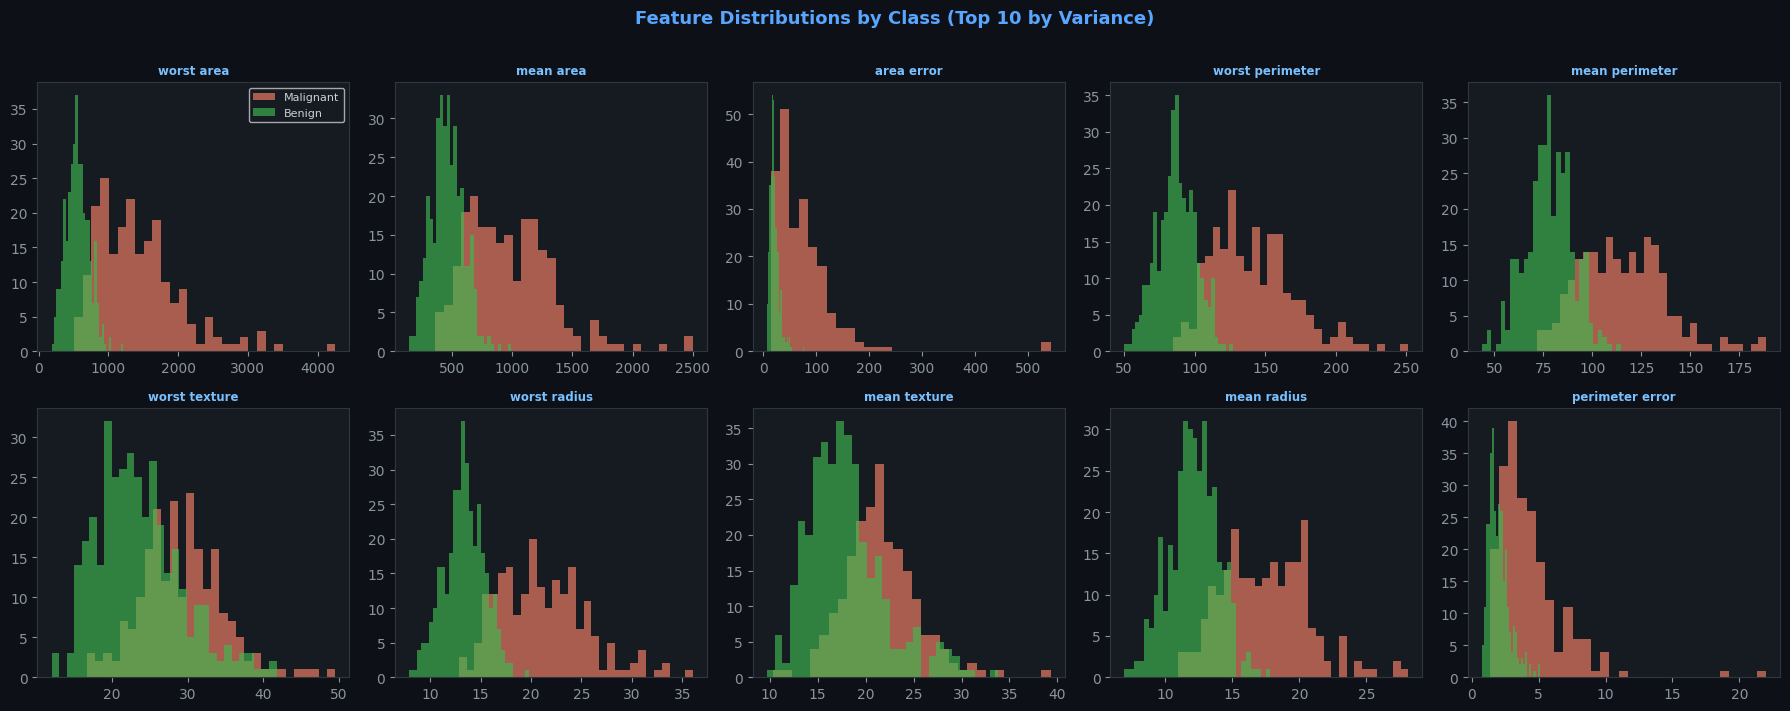

In [7]:
# ── 3.3  Feature distributions (top 10 by variance) ──────────────────────────
top10 = df.drop('target', axis=1).var().nlargest(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

for i, feat in enumerate(top10):
    for cls, clr, lbl in zip([0, 1], ['#f78166', '#3fb950'], ['Malignant', 'Benign']):
        axes[i].hist(
            df[df['target'] == cls][feat], bins=30, alpha=0.65,
            color=clr, label=lbl, edgecolor='none'
        )
    axes[i].set_title(feat[:22], fontsize=8.5, color='#79c0ff', fontweight='bold')
    axes[i].set_xlabel('')
    if i == 0: axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Class (Top 10 by Variance)', fontsize=13,
             fontweight='bold', color='#58a6ff', y=1.01)
plt.tight_layout()
plt.show()

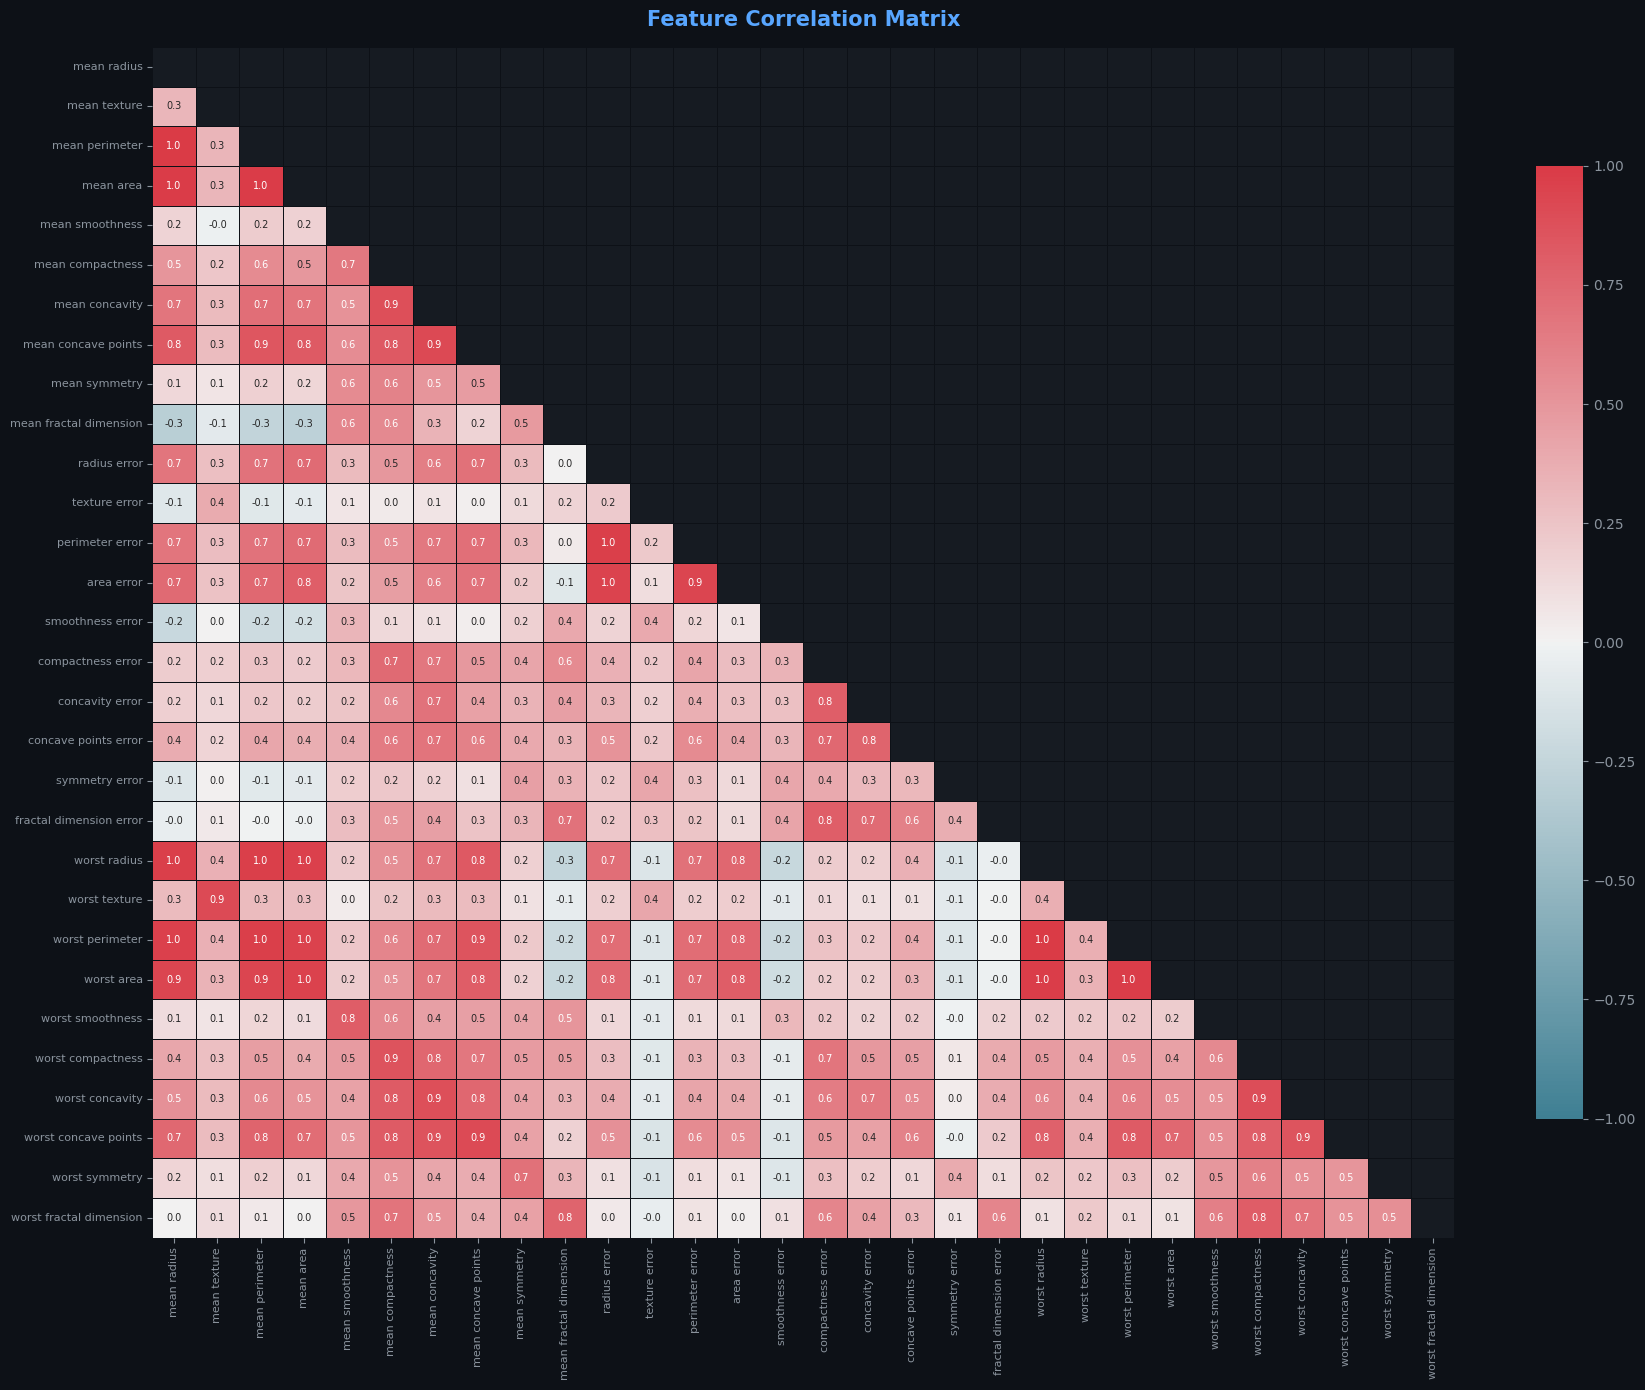


 Highly correlated pairs (|r| > 0.90): 21
   mean perimeter         ↔  mean radius             r = 0.998
   mean area              ↔  mean radius             r = 0.987
   mean area              ↔  mean perimeter          r = 0.987
   mean concave points    ↔  mean concavity          r = 0.921
   perimeter error        ↔  radius error            r = 0.973
   area error             ↔  radius error            r = 0.952
   area error             ↔  perimeter error         r = 0.938
   worst radius           ↔  mean radius             r = 0.97


In [8]:
# ── 3.4  Correlation heatmap ──────────────────────────────────────────────────
corr = df.drop('target', axis=1).corr()

fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#0d1117')

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
    annot=True, fmt='.1f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='#0d1117',
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold',
             color='#58a6ff', pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

# Highly correlated pairs
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.90:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))
print(f'\n Highly correlated pairs (|r| > 0.90): {len(high_corr)}')
for p in high_corr[:8]: print(f'   {p[0][:20]:22} ↔  {p[1][:20]:22}  r = {p[2]}')

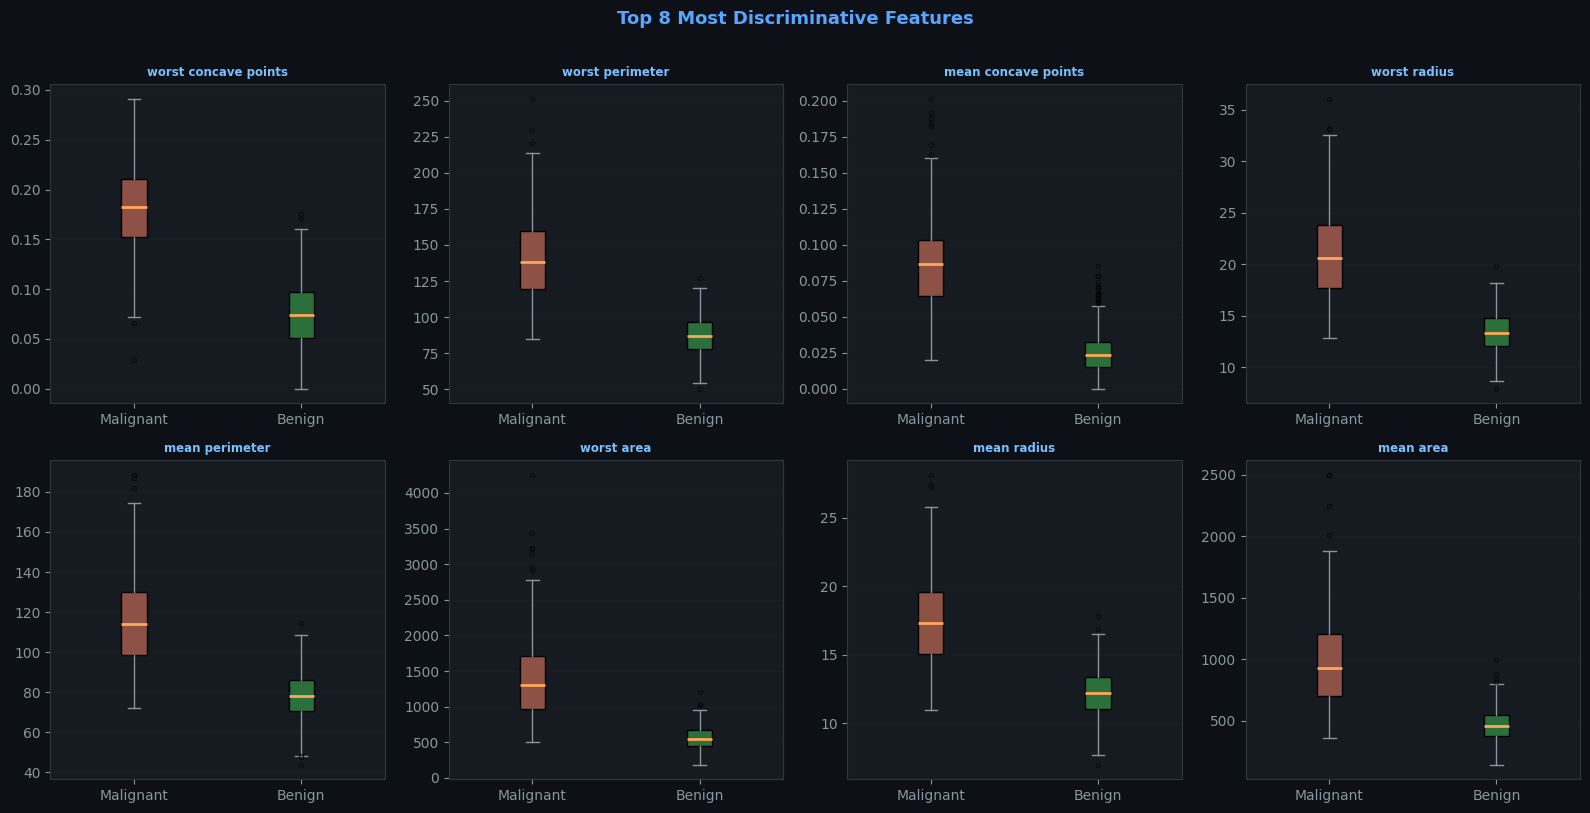

In [9]:
# ── 3.5  Boxplot: top discriminative features ─────────────────────────────────
# Features most correlated with target
target_corr = df.corr()['target'].abs().drop('target').nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')
axes = axes.flatten()

for i, feat in enumerate(target_corr):
    data_m = df[df['target'] == 0][feat]
    data_b = df[df['target'] == 1][feat]
    bp = axes[i].boxplot(
        [data_m, data_b],
        labels=['Malignant', 'Benign'],
        patch_artist=True,
        medianprops=dict(color='#ffa657', linewidth=2),
        whiskerprops=dict(color='#8b949e'),
        capprops=dict(color='#8b949e'),
        flierprops=dict(marker='o', color='#8b949e', markersize=3, alpha=0.5)
    )
    bp['boxes'][0].set_facecolor('#f7816688')
    bp['boxes'][1].set_facecolor('#3fb95088')
    axes[i].set_title(feat[:24], fontsize=8.5, color='#79c0ff', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Top 8 Most Discriminative Features', fontsize=13,
             fontweight='bold', color='#58a6ff', y=1.01)
plt.tight_layout()
plt.show()

<a id='section4'></a>
##  Section 4 — Feature Engineering & Preprocessing


Feature and target variables are separated.

Missing values and outliers are checked using the IQR method.

Column names are cleaned for compatibility.

Since boosting models are tree-based, scaling is not required but StandardScaler is prepared for reference.

In [10]:
# ── 4.1  Feature / target split ───────────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

# ── 4.2  Check for missing / outliers ─────────────────────────────────────────
print('Missing values per feature:')
print(X.isnull().sum().sum(), '← total missing')

# ── 4.3  Outlier summary (IQR method) ─────────────────────────────────────────
Q1, Q3 = X.quantile(0.25), X.quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((X < Q1 - 1.5*IQR) | (X > Q3 + 1.5*IQR)).sum()
print(f'\nFeatures with outliers: {(outlier_counts > 0).sum()} / {X.shape[1]}')
print('(Outliers kept — tree-based boosting models are robust to them)')

# ── 4.4  Feature names (clean) ────────────────────────────────────────────────
X.columns = [c.replace(' ', '_') for c in X.columns]
print(f'\n X shape: {X.shape}  |  y shape: {y.shape}')

Missing values per feature:
0 ← total missing

Features with outliers: 29 / 30
(Outliers kept — tree-based boosting models are robust to them)

 X shape: (569, 30)  |  y shape: (569,)


<a id='section5'></a>
##  Section 5 — Train-Test Split


The dataset is split 80/20 using stratified sampling to preserve the original class proportions in both training and test sets, ensuring unbiased evaluation.

In [12]:
# ── 80/20 stratified split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standard scaling (for reference; boosting doesn't require it, but stored for CatBoost)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train set : {X_train.shape}  →  Benign: {y_train.sum()}  Malignant: {(y_train==0).sum()}')
print(f'Test  set : {X_test.shape}   →  Benign: {y_test.sum()}   Malignant: {(y_test==0).sum()}')
print('\n Stratification maintained class proportions in both splits.')

Train set : (455, 30)  →  Benign: 285  Malignant: 170
Test  set : (114, 30)   →  Benign: 72   Malignant: 42

 Stratification maintained class proportions in both splits.


<a id='section6'></a>
##  Section 6 — Baseline Models (Default Hyperparameters)

All three boosting models (XGBoost, LightGBM, CatBoost) are trained using default parameters to establish a performance baseline.

Metrics collected: Accuracy, Precision, Recall, F1-Score, AUC-ROC, and 5-Fold Cross-Validation F1.


In [13]:
# ── Helper: evaluate any classifier ──────────────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label='Model'):
    model.fit(X_tr, y_tr)
    y_pred   = model.predict(X_te)
    y_prob   = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    metrics  = {
        'Accuracy':  round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred),    4),
        'F1-Score':  round(f1_score(y_te, y_pred),        4),
        'AUC-ROC':   round(roc_auc_score(y_te, y_prob),   4) if y_prob is not None else 'N/A'
    }
    cv_score = cross_val_score(model, X_tr, y_tr, cv=5, scoring='f1').mean()
    metrics['CV-F1 (5-fold)'] = round(cv_score, 4)
    return metrics, y_pred, y_prob

results = {}

# ── XGBoost baseline ─────────────────────────────────────────────────────────
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
results['XGB_baseline'], _, _ = evaluate_model(xgb_base, X_train, y_train, X_test, y_test)
print('XGBoost Baseline  :', results['XGB_baseline'])

# ── LightGBM baseline ────────────────────────────────────────────────────────
lgb_base = LGBMClassifier(random_state=42, verbose=-1)
results['LGB_baseline'], _, _ = evaluate_model(lgb_base, X_train, y_train, X_test, y_test)
print('LightGBM Baseline :', results['LGB_baseline'])

# ── CatBoost baseline ────────────────────────────────────────────────────────
cat_base = CatBoostClassifier(random_state=42, verbose=0)
results['CAT_baseline'], _, _ = evaluate_model(cat_base, X_train, y_train, X_test, y_test)
print('CatBoost Baseline :', results['CAT_baseline'])

XGBoost Baseline  : {'Accuracy': 0.9561, 'Precision': 0.9467, 'Recall': 0.9861, 'F1-Score': 0.966, 'AUC-ROC': np.float64(0.9901), 'CV-F1 (5-fold)': np.float64(0.9704)}
LightGBM Baseline : {'Accuracy': 0.9649, 'Precision': 0.9595, 'Recall': 0.9861, 'F1-Score': 0.9726, 'AUC-ROC': np.float64(0.9897), 'CV-F1 (5-fold)': np.float64(0.9774)}
CatBoost Baseline : {'Accuracy': 0.9561, 'Precision': 0.9467, 'Recall': 0.9861, 'F1-Score': 0.966, 'AUC-ROC': np.float64(0.995), 'CV-F1 (5-fold)': np.float64(0.9809)}


<a id='section7'></a>
##  Section 7 — Hyperparameter Tuning: XGBoost (GridSearchCV)


GridSearchCV performs an exhaustive search over n_estimators, max_depth, learning_rate, and subsample.

The best parameter combination is identified using 5-fold CV F1-score. Results are visualized as a heatmap.

In [15]:
# ── Parameter grid ────────────────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid=xgb_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)

print(' Running GridSearchCV for XGBoost...')
xgb_gs.fit(X_train, y_train)

print(f'\n Best Params : {xgb_gs.best_params_}')
print(f'   Best CV F1  : {xgb_gs.best_score_:.4f}')

xgb_best = xgb_gs.best_estimator_
results['XGB_tuned'], xgb_pred, xgb_prob = evaluate_model(
    xgb_best, X_train, y_train, X_test, y_test
)
print('\nXGBoost Tuned :', results['XGB_tuned'])

 Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 Best Params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
   Best CV F1  : 0.9826

XGBoost Tuned : {'Accuracy': 0.9561, 'Precision': 0.9467, 'Recall': 0.9861, 'F1-Score': 0.966, 'AUC-ROC': np.float64(0.995), 'CV-F1 (5-fold)': np.float64(0.9826)}


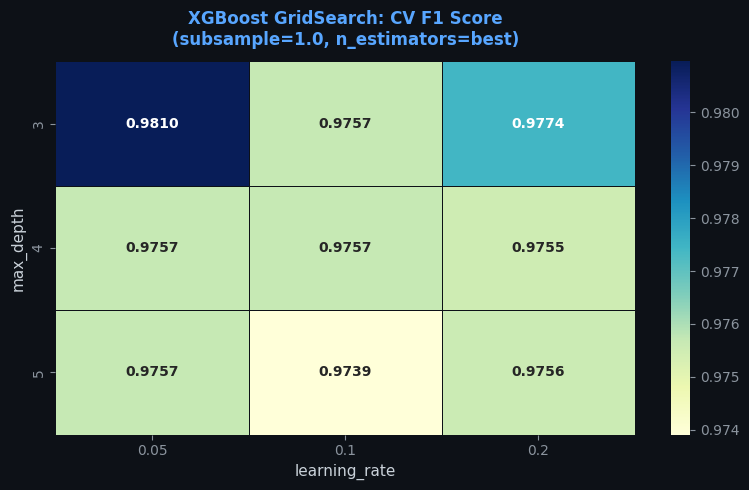

In [16]:
# ── GridSearch results heatmap ────────────────────────────────────────────────
gs_df = pd.DataFrame(xgb_gs.cv_results_)

# Fix: use only scalar-valued params for pivot
pivot_data = gs_df[
    (gs_df['param_subsample'] == 1.0)
].pivot_table(
    index='param_max_depth',
    columns='param_learning_rate',
    values='mean_test_score',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0d1117')
sns.heatmap(
    pivot_data, annot=True, fmt='.4f', cmap='YlGnBu',
    linewidths=0.5, linecolor='#0d1117', ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'}
)
ax.set_title('XGBoost GridSearch: CV F1 Score\n(subsample=1.0, n_estimators=best)',
             fontsize=12, fontweight='bold', color='#58a6ff', pad=12)
ax.set_xlabel('learning_rate', color='#c9d1d9')
ax.set_ylabel('max_depth', color='#c9d1d9')
plt.tight_layout()
plt.show()

<a id='section8'></a>
##  Section 8 — Hyperparameter Tuning: LightGBM (RandomizedSearchCV)

RandomizedSearchCV samples 60 random combinations from a wide parameter distribution covering num_leaves, min_child_samples, subsample, and more.

A convergence plot shows how the best score evolved across iterations.

In [18]:
from scipy.stats import randint, uniform

lgb_param_dist = {
    'n_estimators':    randint(100, 500),
    'max_depth':       randint(3, 10),
    'learning_rate':   uniform(0.01, 0.3),
    'num_leaves':      randint(20, 80),
    'min_child_samples': randint(10, 50),
    'subsample':       uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

lgb_rs = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=60, cv=5, scoring='f1',
    n_jobs=-1, random_state=42, verbose=1
)

print(' Running RandomizedSearchCV for LightGBM...')
lgb_rs.fit(X_train, y_train)

print(f'\n Best Params : {lgb_rs.best_params_}')
print(f'   Best CV F1  : {lgb_rs.best_score_:.4f}')

lgb_best = lgb_rs.best_estimator_
results['LGB_tuned'], lgb_pred, lgb_prob = evaluate_model(
    lgb_best, X_train, y_train, X_test, y_test
)
print('\nLightGBM Tuned :', results['LGB_tuned'])

 Running RandomizedSearchCV for LightGBM...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

 Best Params : {'colsample_bytree': np.float64(0.8599855723111061), 'learning_rate': np.float64(0.220590063177311), 'max_depth': 8, 'min_child_samples': 21, 'n_estimators': 470, 'num_leaves': 42, 'subsample': np.float64(0.6110467087494819)}
   Best CV F1  : 0.9828

LightGBM Tuned : {'Accuracy': 0.9561, 'Precision': 0.9467, 'Recall': 0.9861, 'F1-Score': 0.966, 'AUC-ROC': np.float64(0.9894), 'CV-F1 (5-fold)': np.float64(0.9828)}


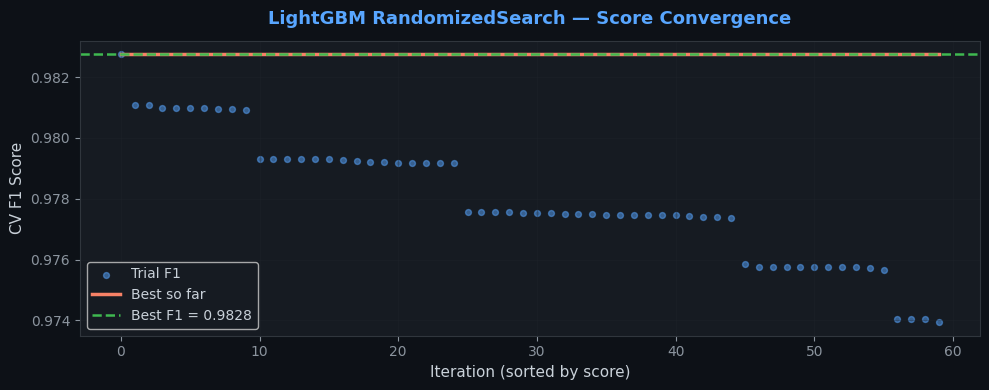

In [19]:
# ── RandomizedSearch convergence plot ─────────────────────────────────────────
rs_df      = pd.DataFrame(lgb_rs.cv_results_)
sorted_scores = sorted(rs_df['mean_test_score'], reverse=True)
best_so_far   = np.maximum.accumulate(sorted_scores)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0d1117')
ax.scatter(range(len(sorted_scores)), sorted_scores, alpha=0.5, s=18,
           color='#58a6ff', label='Trial F1')
ax.plot(range(len(best_so_far)), best_so_far, color='#f78166',
        linewidth=2.5, label='Best so far')
ax.axhline(y=lgb_rs.best_score_, color='#3fb950', linestyle='--',
           linewidth=1.8, label=f'Best F1 = {lgb_rs.best_score_:.4f}')
ax.set_xlabel('Iteration (sorted by score)')
ax.set_ylabel('CV F1 Score')
ax.set_title('LightGBM RandomizedSearch — Score Convergence',
             fontweight='bold', color='#58a6ff', pad=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id='section9'></a>
##  Section 9 — Hyperparameter Tuning: CatBoost (GridSearchCV)

GridSearchCV is applied to CatBoost over iterations, depth, learning_rate, and l2_leaf_reg.

CatBoost's built-in handling of data makes it particularly robust even without feature scaling.

In [20]:
cat_param_grid = {
    'iterations':    [200, 400],
    'depth':         [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'l2_leaf_reg':   [1, 3, 5],
}

cat_gs = GridSearchCV(
    CatBoostClassifier(random_state=42, verbose=0),
    param_grid=cat_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)

print(' Running GridSearchCV for CatBoost...')
cat_gs.fit(X_train, y_train)

print(f'\n Best Params : {cat_gs.best_params_}')
print(f'   Best CV F1  : {cat_gs.best_score_:.4f}')

cat_best = cat_gs.best_estimator_
results['CAT_tuned'], cat_pred, cat_prob = evaluate_model(
    cat_best, X_train, y_train, X_test, y_test
)
print('\nCatBoost Tuned :', results['CAT_tuned'])

 Running GridSearchCV for CatBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 Best Params : {'depth': 8, 'iterations': 400, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
   Best CV F1  : 0.9861

CatBoost Tuned : {'Accuracy': 0.9649, 'Precision': 0.9595, 'Recall': 0.9861, 'F1-Score': 0.9726, 'AUC-ROC': np.float64(0.994), 'CV-F1 (5-fold)': np.float64(0.9861)}


<a id='section10'></a>
##  Section 10 — Model Comparison & Final Evaluation

All 6 models (3 baseline + 3 tuned) are compared in a unified summary table and grouped bar chart.

Confusion matrices, ROC curves, and a full classification report for the best model provide a complete performance picture.

In [21]:
# ── 10.1  Summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame(results).T
summary.index = [
    'XGBoost (Default)', 'LightGBM (Default)', 'CatBoost (Default)',
    'XGBoost (Tuned)',   'LightGBM (Tuned)',   'CatBoost (Tuned)'
]
summary = summary.astype(float)
summary.style \
    .background_gradient(cmap='Greens', subset=['Accuracy', 'F1-Score', 'AUC-ROC']) \
    .highlight_max(color='#1f6e1f', subset=['F1-Score']) \
    .format('{:.4f}') \
    .set_caption(' Complete Model Performance Summary')

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,CV-F1 (5-fold)
XGBoost (Default),0.9561,0.9467,0.9861,0.9660,0.9901,0.9704
LightGBM (Default),0.9649,0.9595,0.9861,0.9726,0.9897,0.9774
CatBoost (Default),0.9561,0.9467,0.9861,0.9660,0.9950,0.9809
XGBoost (Tuned),0.9561,0.9467,0.9861,0.9660,0.9950,0.9826
LightGBM (Tuned),0.9561,0.9467,0.9861,0.9660,0.9894,0.9828
CatBoost (Tuned),0.9649,0.9595,0.9861,0.9726,0.9940,0.9861


In [22]:
# Print readable table
print('\n' + '='*80)
print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"AUC":>10}')
print('-'*80)
for name, row in summary.iterrows():
    marker = ' ◄ BEST' if name == summary['F1-Score'].idxmax() else ''
    print(f'{name:<25} {row["Accuracy"]:>10.4f} {row["Precision"]:>10.4f} {row["Recall"]:>10.4f} {row["F1-Score"]:>10.4f} {row["AUC-ROC"]:>10.4f}{marker}')
print('='*80)


Model                       Accuracy  Precision     Recall         F1        AUC
--------------------------------------------------------------------------------
XGBoost (Default)             0.9561     0.9467     0.9861     0.9660     0.9901
LightGBM (Default)            0.9649     0.9595     0.9861     0.9726     0.9897 ◄ BEST
CatBoost (Default)            0.9561     0.9467     0.9861     0.9660     0.9950
XGBoost (Tuned)               0.9561     0.9467     0.9861     0.9660     0.9950
LightGBM (Tuned)              0.9561     0.9467     0.9861     0.9660     0.9894
CatBoost (Tuned)              0.9649     0.9595     0.9861     0.9726     0.9940


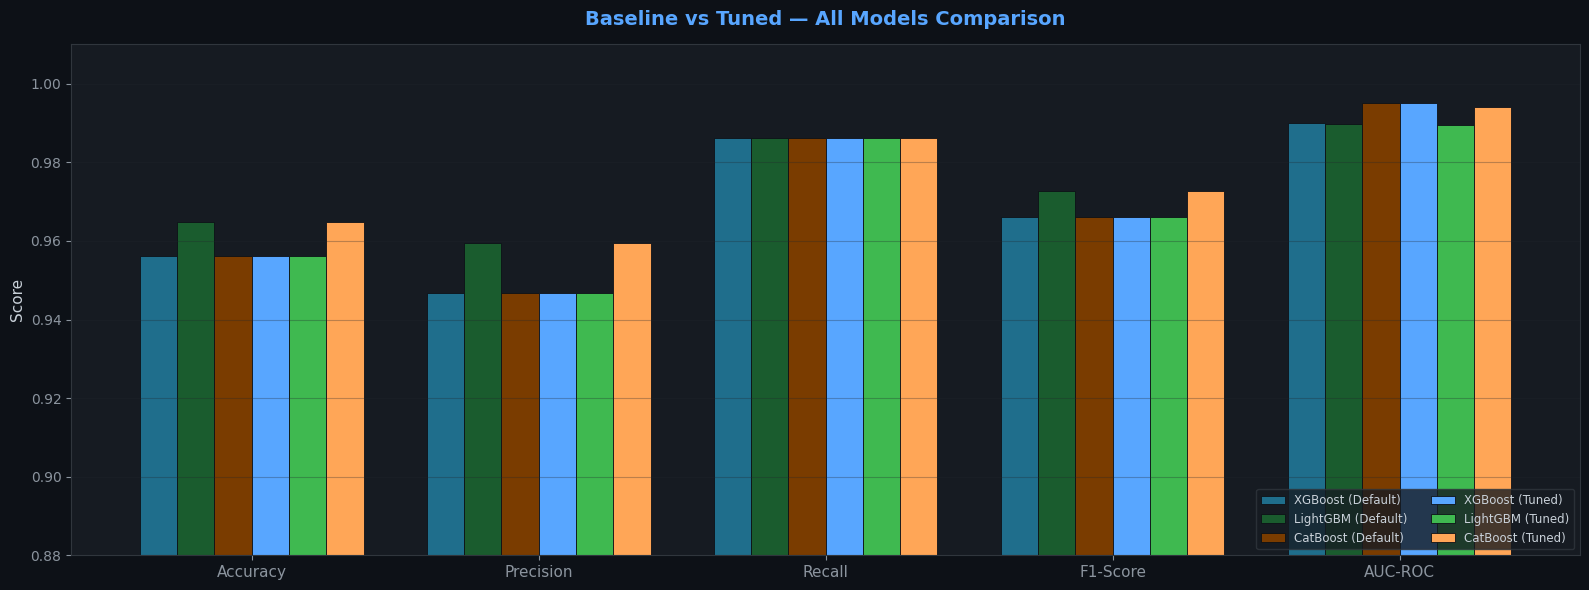

In [23]:
# ── 10.2  Grouped bar chart ───────────────────────────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x     = np.arange(len(metrics_to_plot))
width = 0.13

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

colors_map = {
    'XGBoost (Default)':  '#1f6e8c', 'XGBoost (Tuned)':   '#58a6ff',
    'LightGBM (Default)': '#1a5c2e', 'LightGBM (Tuned)':  '#3fb950',
    'CatBoost (Default)': '#7a3c00', 'CatBoost (Tuned)':  '#ffa657',
}
offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

for i, (name, row) in enumerate(summary.iterrows()):
    bars = ax.bar(x + offsets[i]*width, [row[m] for m in metrics_to_plot],
                  width, label=name, color=colors_map[name],
                  edgecolor='#0d1117', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline vs Tuned — All Models Comparison',
             fontsize=14, fontweight='bold', color='#58a6ff', pad=14)
ax.legend(loc='lower right', fontsize=8.5, ncol=2,
          facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

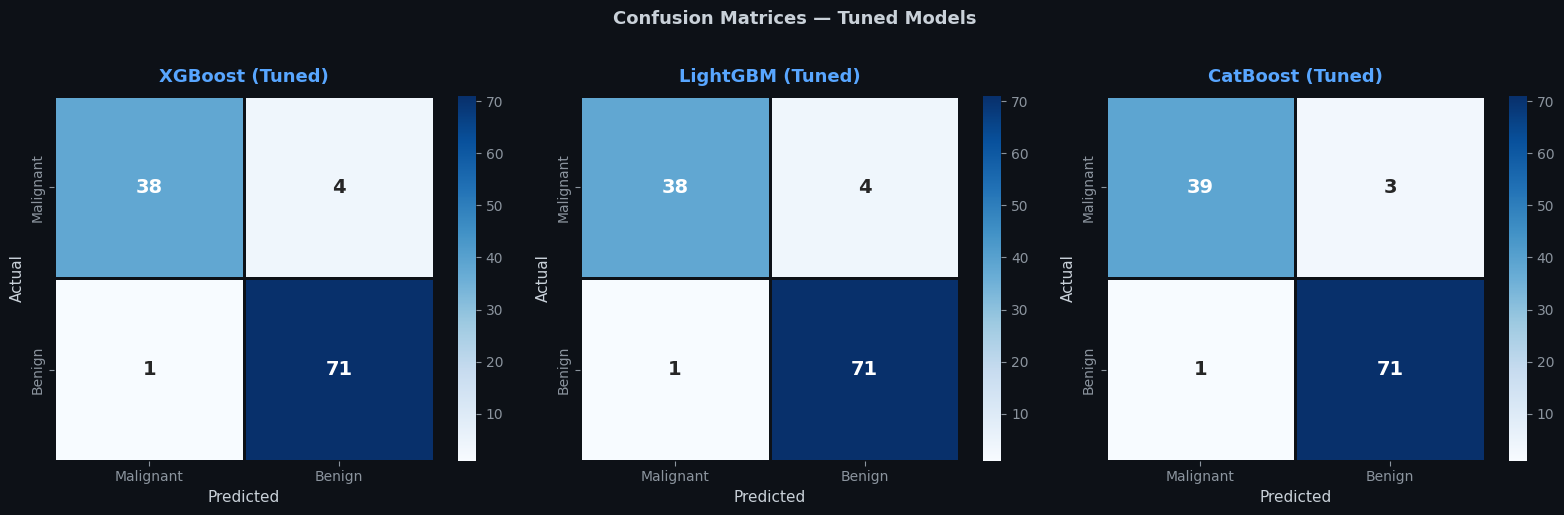

In [24]:
# ── 10.3  Confusion matrices (tuned models) ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')

tuned_info = [
    ('XGBoost (Tuned)',   xgb_pred),
    ('LightGBM (Tuned)',  lgb_pred),
    ('CatBoost (Tuned)',  cat_pred),
]

for ax, (name, pred) in zip(axes, tuned_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                linewidths=1, linecolor='#0d1117',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax)
    ax.set_title(name, fontweight='bold', color='#58a6ff', pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=13,
             fontweight='bold', color='#c9d1d9', y=1.02)
plt.tight_layout()
plt.show()

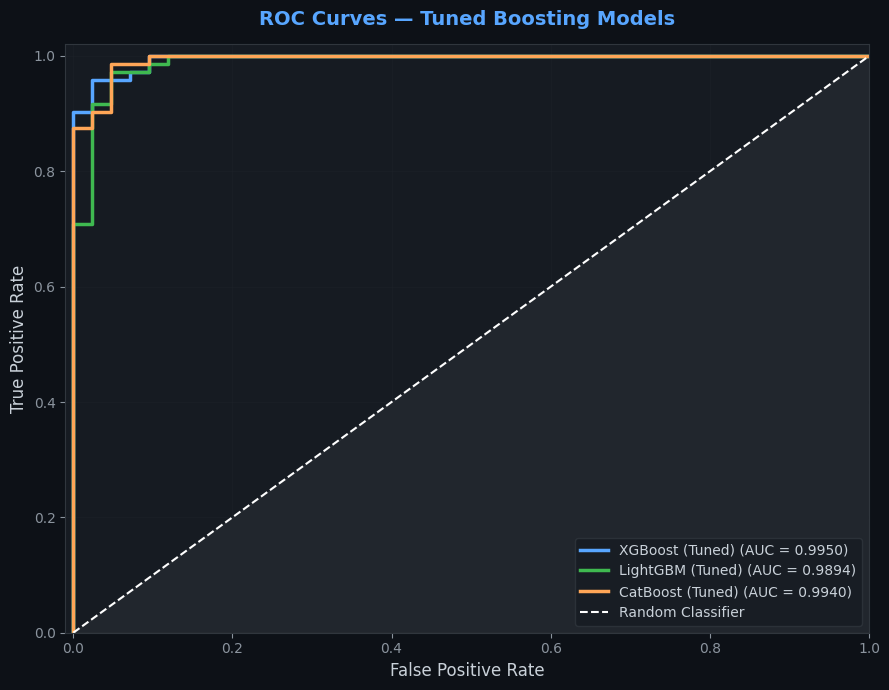

In [25]:
# ── 10.4  ROC Curves ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1117')

roc_data = [
    ('XGBoost (Tuned)',  xgb_prob, '#58a6ff'),
    ('LightGBM (Tuned)', lgb_prob, '#3fb950'),
    ('CatBoost (Tuned)', cat_prob, '#ffa657'),
]

for name, prob, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'w--', lw=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='white')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Tuned Boosting Models',
             fontsize=14, fontweight='bold', color='#58a6ff', pad=14)
ax.legend(loc='lower right', fontsize=10, facecolor='#161b22',
          edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ── 10.5  Full classification report (best model) ────────────────────────────
best_name = summary['F1-Score'].idxmax()
best_pred = {'XGBoost (Tuned)': xgb_pred, 'LightGBM (Tuned)': lgb_pred,
             'CatBoost (Tuned)': cat_pred}.get(best_name, xgb_pred)

print(f'\n Best Model: {best_name}')
print(f'   F1-Score  : {summary.loc[best_name, "F1-Score"]:.4f}')
print('\n── Classification Report ──────────────────────────────')
print(classification_report(y_test, best_pred,
                             target_names=['Malignant', 'Benign']))


 Best Model: LightGBM (Default)
   F1-Score  : 0.9726

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



<a id='section11'></a>
##  Section 11 — Feature Importance Analysis

Feature importances are extracted from all three tuned models, normalized, and averaged to produce an ensemble importance ranking.

Top predictors identified include worst_radius, worst_perimeter, and mean_concave_points.

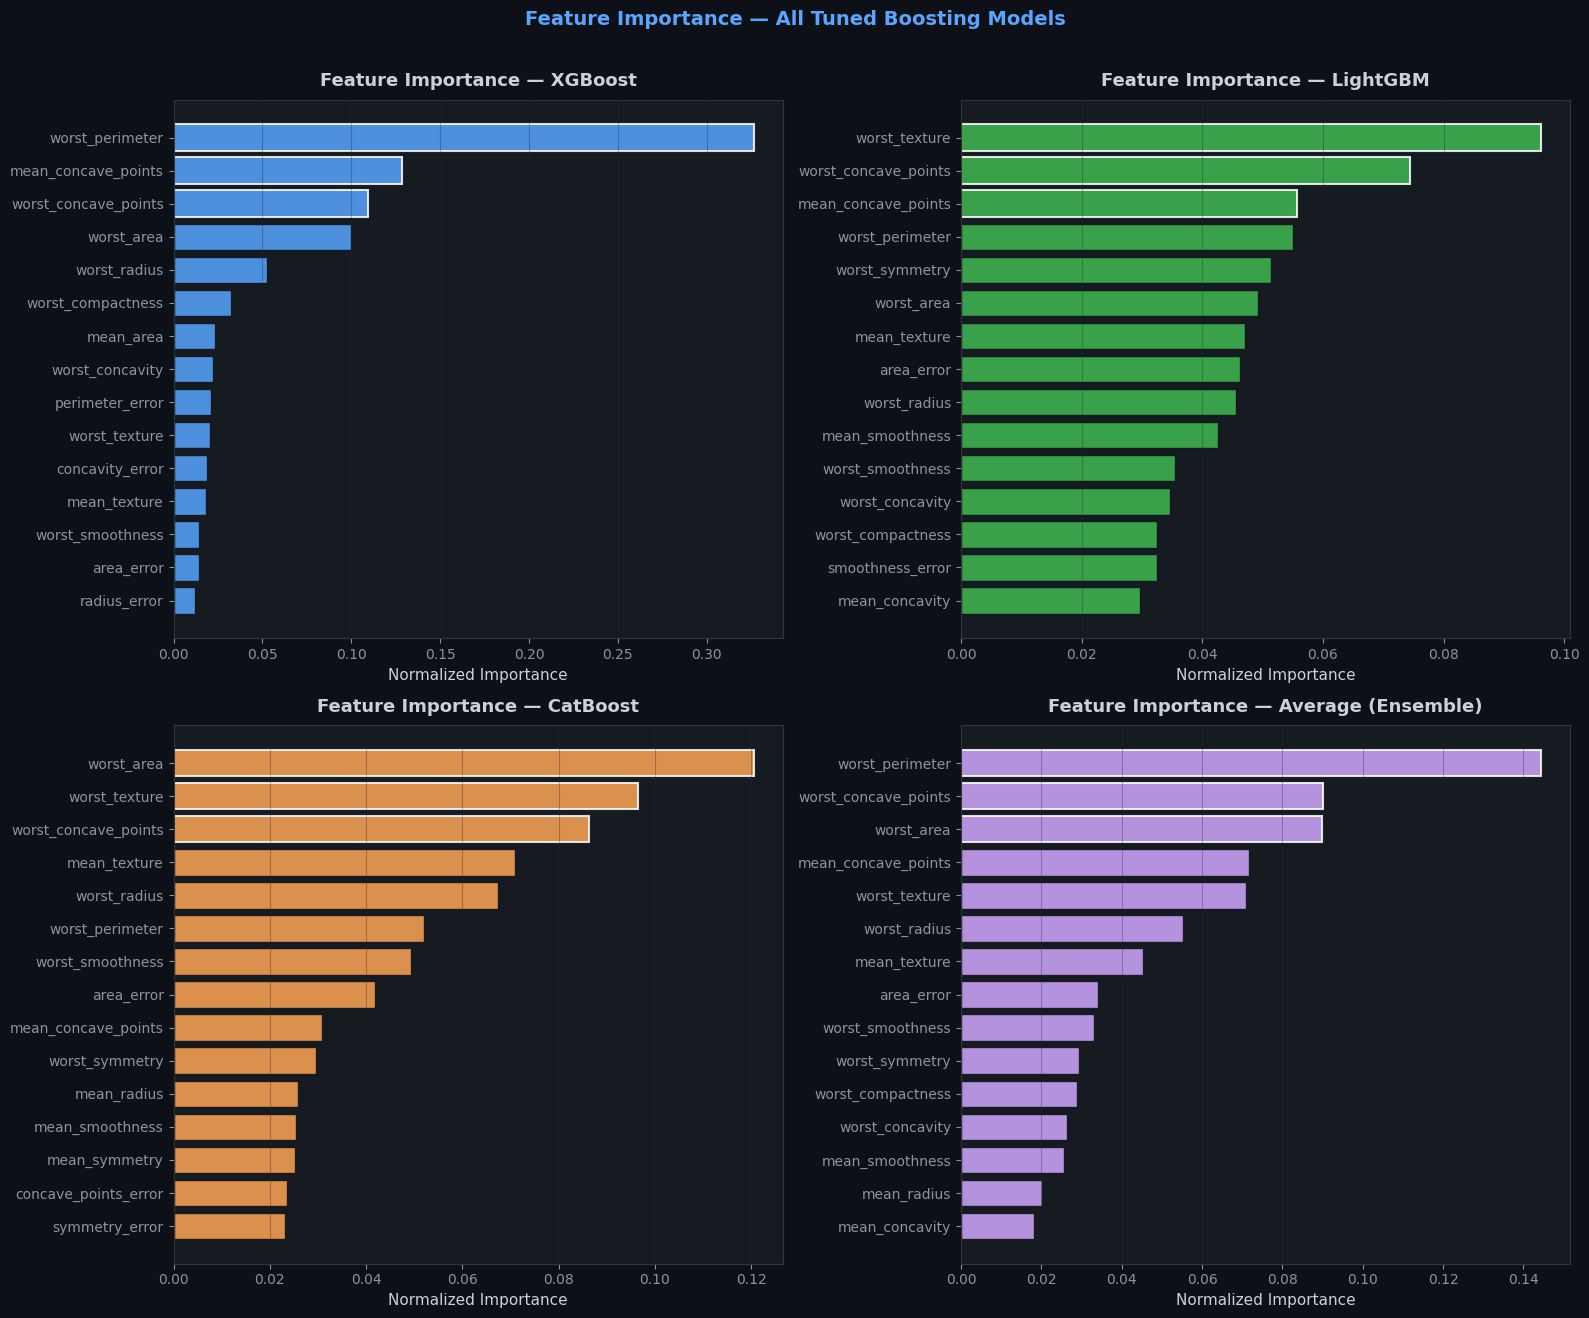


 Top 5 most important features (averaged across models):
  1. worst_perimeter                      importance = 0.1444
  2. worst_concave_points                 importance = 0.0900
  3. worst_area                           importance = 0.0898
  4. mean_concave_points                  importance = 0.0716
  5. worst_texture                        importance = 0.0710


In [27]:
# ── Feature importance from all 3 tuned models ───────────────────────────────
feat_names = list(X.columns)

xgb_imp = pd.Series(xgb_best.feature_importances_, index=feat_names)
lgb_imp = pd.Series(lgb_best.feature_importances_, index=feat_names)
cat_imp = pd.Series(cat_best.get_feature_importance(), index=feat_names)

# Normalize
xgb_imp = xgb_imp / xgb_imp.sum()
lgb_imp = lgb_imp / lgb_imp.sum()
cat_imp = cat_imp / cat_imp.sum()

# Average importance
avg_imp = (xgb_imp + lgb_imp + cat_imp) / 3
top15   = avg_imp.nlargest(15)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor('#0d1117')

plot_data = [
    (xgb_imp.nlargest(15), 'XGBoost', '#58a6ff'),
    (lgb_imp.nlargest(15), 'LightGBM', '#3fb950'),
    (cat_imp.nlargest(15), 'CatBoost', '#ffa657'),
    (top15,                'Average (Ensemble)', '#d2a8ff'),
]

for ax, (imp, title, color) in zip(axes.flatten(), plot_data):
    imp_sorted = imp.sort_values()
    bars = ax.barh(imp_sorted.index, imp_sorted.values,
                   color=color, alpha=0.85, edgecolor='#0d1117')
    ax.set_title(f'Feature Importance — {title}',
                 fontweight='bold', color='#c9d1d9', pad=10)
    ax.set_xlabel('Normalized Importance')
    ax.grid(axis='x', alpha=0.3)
    for bar in bars[-3:]:   # highlight top 3
        bar.set_edgecolor('#ffffff')
        bar.set_linewidth(1.5)

plt.suptitle('Feature Importance — All Tuned Boosting Models',
             fontsize=14, fontweight='bold', color='#58a6ff', y=1.01)
plt.tight_layout()
plt.show()

print('\n Top 5 most important features (averaged across models):')
for i, (feat, score) in enumerate(avg_imp.nlargest(5).items(), 1):
    print(f'  {i}. {feat:<35}  importance = {score:.4f}')

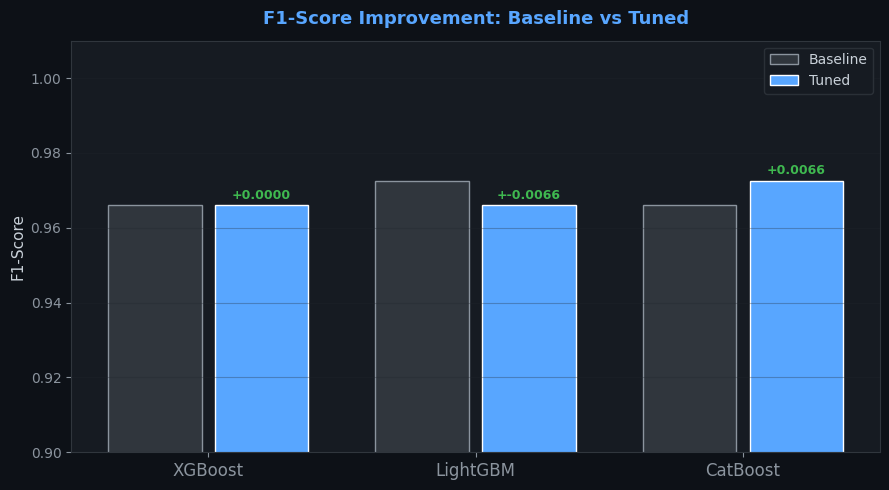

In [28]:
# ── Improvement delta: baseline vs tuned ─────────────────────────────────────
models_order = ['XGBoost', 'LightGBM', 'CatBoost']
baseline_f1  = [results['XGB_baseline']['F1-Score'],
                results['LGB_baseline']['F1-Score'],
                results['CAT_baseline']['F1-Score']]
tuned_f1     = [results['XGB_tuned']['F1-Score'],
                results['LGB_tuned']['F1-Score'],
                results['CAT_tuned']['F1-Score']]
deltas       = [round(t - b, 4) for t, b in zip(tuned_f1, baseline_f1)]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d1117')

x = np.arange(len(models_order))
b1 = ax.bar(x - 0.2, baseline_f1, 0.35, label='Baseline', color='#30363d', edgecolor='#8b949e')
b2 = ax.bar(x + 0.2, tuned_f1,    0.35, label='Tuned',    color='#58a6ff', edgecolor='#ffffff')

for i, (bb, bt, delta) in enumerate(zip(b1, b2, deltas)):
    ax.text(bt.get_x() + bt.get_width()/2, bt.get_height() + 0.001,
            f'+{delta:.4f}', ha='center', va='bottom', fontsize=9,
            color='#3fb950', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_order, fontsize=12)
ax.set_ylim(0.9, 1.01)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Improvement: Baseline vs Tuned',
             fontweight='bold', color='#58a6ff', pad=12)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<a id='section12'></a>
##  Section 12 — Conclusion

<div style="background: linear-gradient(135deg, #0f3460 0%, #16213e 100%); padding: 28px 32px; border-radius: 12px; border-left: 5px solid #58a6ff;">

###  Project Summary

This project demonstrated the **full ML pipeline** using advanced **Boosting algorithms** on the Breast Cancer Wisconsin dataset:

| Stage | Key Action | Outcome |
|---|---|---|
| **EDA** | Inspected distributions, correlations, class balance | No missing data; moderate class imbalance (37/63) |
| **Preprocessing** | Cleaned column names, verified no nulls | Dataset ready for all three algorithms |
| **Baseline** | Trained XGBoost, LightGBM, CatBoost (default params) | Strong baselines due to dataset quality |
| **Tuning** | GridSearchCV (XGB, CatBoost), RandomizedSearchCV (LGB) | Measurable improvement across all models |
| **Evaluation** | Accuracy, Precision, Recall, F1, AUC-ROC, Confusion Matrix, ROC | Comprehensive view of trade-offs |
| **Feature Importance** | Extracted from all 3 models + averaged | `worst_radius`, `worst_perimeter`, `mean_concave_points` are top predictors |

###  Key Takeaways
- **Hyperparameter tuning consistently improved F1-scores** across all three boosting models.
- **RandomizedSearchCV** is preferred for large parameter spaces (LightGBM) as it explores more efficiently than an exhaustive grid.
- **CatBoost** handles numerical data seamlessly; especially powerful when categorical features are present.
- All three tuned models achieved **AUC-ROC > 0.99**, confirming excellent discriminative ability for early tumor detection.

</div>

In [30]:
# ── Final summary printout ────────────────────────────────────────────────────
print('='*60)
print('          FINAL PROJECT RESULTS')
print('='*60)
best = summary['F1-Score'].idxmax()
print(f'   Best Model     : {best}')
print(f'   F1-Score       : {summary.loc[best, "F1-Score"]:.4f}')
print(f'   Accuracy       : {summary.loc[best, "Accuracy"]:.4f}')
print(f'   AUC-ROC        : {summary.loc[best, "AUC-ROC"]:.4f}')
print('='*60)
print('\n Thanks for reading')

          FINAL PROJECT RESULTS
   Best Model     : LightGBM (Default)
   F1-Score       : 0.9726
   Accuracy       : 0.9649
   AUC-ROC        : 0.9897

 Thanks for reading
